# Predicting the Unpredictable
# Task 1 — VIL 12→12 Forecasting Report

# Introduction

**Task definition.** Given the first 12 frames of a single storm’s VIL (Vertically Integrated Liquid) radar product (Frame 1–Frame 12), predict the next 12 frames (Frame 13–Frame 24).

**Input / output.** For each storm, `vil` is stored as a `(384, 384, 36)` `uint8` array. We convert it to floats in `[0,1]` and work with tensors shaped:
- Input: $x ∈ R^{12×1×384×384}$
- Target: $y ∈ R^{12×1×384×384}$

**Approach overview.** I start with a simple convolutional baseline (direct 12→12 regression), then extend to a ConvLSTM-UNet model to better capture spatiotemporal dynamics and preserve intense storm cores.

**Report structure.** I first summarize relevant EDA findings and preprocessing decisions, then define metrics and compare the baseline vs the extension using both quantitative scores and qualitative frame visualizations.

# Data Exploration

### Data contract (what one storm looks like)

The training HDF5 file stores each storm under a group keyed by `id`. For each storm, `vil` is a 36-frame sequence:

- `vil` has shape `(384, 384, 36)` and dtype `uint8`.
- In the EDA sample, `vil` values often ranged from 0 up to ~211 (so the practical maximum can be below 255).

This means each frame is a 384×384 image, and each storm provides 36 frames total (enough to form multiple 12→12 windows).

### EDA observations that matter for Task 1

From inspecting multiple storms:

- **Long-tailed intensities**: most pixels are low VIL, while strong storm cores occupy a small fraction of pixels.
- **Temporal evolution varies**: some storms evolve slowly (strong persistence), while others have rapid motion/intensity changes.
- **“Empty-frame” vs “core” imbalance**: thresholded area fractions such as `VIL>20/40/80` can be very small for many frames, which encourages models trained with plain L1 to under-predict peaks.

These observations motivate: (i) a simple normalization (`/255.0`) and (ii) for the extension model, losses that emphasize later lead times and high-VIL pixels.

**Insert figures here (from EDA notebook):**
- **Figure A**: One example storm — frames 1–12 (input) and 13–24 (target) in a grid.
- **Figure B**: Per-frame mean/std and quantiles across t=0..35 (uint8 or scaled), to show drift/scale stability.
- **Figure C**: Mean(|ΔVIL|) per step and thresholded area fraction curves (e.g., `VIL>20/40/80`).

In [ ]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from predicting_unpredictable import data

SEED = 20260126
rng = np.random.default_rng(SEED)

DATA_DIR = Path("data")
TRAIN_H5 = DATA_DIR / "train.h5"
EVENTS_CSV = DATA_DIR / "events.csv"

df = data.read_events_csv(EVENTS_CSV)

sid = str(rng.choice(df["id"].unique()))
print("Task1 example storm:", sid)

with data.open_h5(TRAIN_H5) as f:
    vil = f[sid]["vil"][:]  # (384,384,36) uint8

x_in = vil[:, :, :12].astype(np.float32) / 255.0
x_tgt = vil[:, :, 12:24].astype(np.float32) / 255.0

# Visualise a few frames
frames = [0, 5, 11]
fig, axs = plt.subplots(2, len(frames), figsize=(12, 5))
for j, ti in enumerate(frames):
    axs[0, j].imshow(x_in[:, :, ti], vmin=0, vmax=1, cmap="turbo")
    axs[0, j].set_title(f"input t={ti+1}")
    axs[0, j].axis("off")
    axs[1, j].imshow(x_tgt[:, :, ti], vmin=0, vmax=1, cmap="turbo")
    axs[1, j].set_title(f"target t={ti+13}")
    axs[1, j].axis("off")
plt.tight_layout()
plt.show()

# Persistence baseline: repeat last input frame
pred_persist = np.repeat(x_in[:, :, 11:12], repeats=12, axis=2)
mae = float(np.mean(np.abs(pred_persist - x_tgt)))
print("Persistence baseline MAE (in [0,1] space):", mae)

# --- Extra EDA: temporal drift, frame-diff, spatial intensity ---
vil_f = vil.astype(np.float32)
T = vil_f.shape[2]

# Per-frame moments + quantiles
qs = [0.01, 0.5, 0.9, 0.99]
frame_mean = vil_f.reshape(-1, T).mean(axis=0)
frame_std = vil_f.reshape(-1, T).std(axis=0)
frame_q = np.stack([np.quantile(vil_f[:, :, t], qs) for t in range(T)], axis=0)

plt.figure(figsize=(10, 3))
plt.plot(frame_mean, label="mean")
plt.fill_between(np.arange(T), frame_mean - frame_std, frame_mean + frame_std, alpha=0.2, label="±1 std")
plt.title("Task1: VIL per-frame mean/std (uint8)")
plt.xlabel("frame t")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
for qi, qv in enumerate(qs):
    plt.plot(frame_q[:, qi], label=f"p{int(qv*100)}")
plt.title("Task1: VIL per-frame quantiles (uint8)")
plt.xlabel("frame t")
plt.legend()
plt.tight_layout()
plt.show()

# Frame-to-frame change intensity
abs_diff = np.abs(vil_f[:, :, 1:] - vil_f[:, :, :-1])
diff_mean = abs_diff.reshape(-1, T - 1).mean(axis=0)
diff_p99 = np.quantile(abs_diff.reshape(-1), 0.99)

plt.figure(figsize=(10, 3))
plt.plot(diff_mean)
plt.title(f"Task1: mean(|ΔVIL|) per step (uint8), global p99≈{diff_p99:.1f}")
plt.xlabel("step t→t+1")
plt.tight_layout()
plt.show()

# Spatial intensity proxy: thresholded area fraction
thresholds = [20, 40, 80, 120]
plt.figure(figsize=(10, 3))
for thr in thresholds:
    frac = (vil_f > thr).reshape(-1, T).mean(axis=0)
    plt.plot(frac, label=f"VIL>{thr}")
plt.title("Task1: thresholded area fraction per frame")
plt.xlabel("frame t")
plt.ylabel("fraction of pixels")
plt.legend(ncol=4)
plt.tight_layout()
plt.show()

# Data Preprocessing

### Normalization and tensor layout

For Task 1 I keep preprocessing deliberately simple:

- Convert `vil` from `uint8` (0–255) to `float32` in `[0,1]` using `vil/255.0`.
- Use the canonical tensor layout `(T, C, H, W)` with `C=1`.

This is implemented by `predicting_unpredictable.preprocess.vil_to_tchw`.

### Windowing (12→12 from 36 frames)

Each storm provides 36 frames. I construct training examples using a sliding 24-frame window:

- input: frames `t ... t+11`
- target: frames `t+12 ... t+23`
  
In actual implementing, I choose to add stride for speed up the training with full dataset.

for all valid start times `t` (so that a single storm yields multiple supervised pairs). This increases the effective number of training examples while keeping the task definition unchanged.

### Train/validation split

To avoid leakage, splitting is done **storm-wise by `id`**, never by individual frames. I use the provided storm-wise stratified split utility (`make_stormwise_stratified_split`) so that the validation set has a similar distribution of storm event types.

**Insert split summary here:**
- Train storms: `[N_train]`
- Validation storms: `[N_val]`
- Seed/version: `[seed] / [version]` (optional)

# Metrics

The official surprise-storm ranking uses **L1 / MAE**. I therefore evaluate models primarily with mean absolute error over:

- all pixels,
- all predicted lead times (Frames 13–24).

Because forecasting difficulty increases with lead time and because high-intensity cores are meteorologically important but sparse, I also report (when helpful):

- **MAE per lead time** (1…12), and
- **high-intensity MAE**, computed only on pixels where the ground-truth `VIL > τ` (e.g. τ = 20/255).

This helps distinguish “looks good on average” models from models that actually preserve storm cores.

**Insert metric summary table here (recommended):**

| Model | Val MAE (overall) | 
|---|---:|
| CNN baseline | 0.05710171274840832|
| ConvLSTM-UNet | 0.04143340471200645

In [ ]:
import torch
from torch.utils.data import DataLoader

from predicting_unpredictable.data import open_h5
from predicting_unpredictable.train.task1 import VilWindowDatasetCNN, VilSeqDataset
from predicting_unpredictable.models.task1 import Task1CNNBaseline, BottleneckConvLSTMUNet
from predicting_unpredictable.split import make_stormwise_stratified_split

h5_path = "data/train.h5"

cnn_ckpt_path  = "notebooks-final/checkpoints/task1_baseline_best.pt"   
unet_ckpt_path = "notebooks-final/checkpoints/task1_unet_best.pt"      

val_ids = sp.val_ids  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def _load_state_dict_any(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        return ckpt["model_state_dict"], ckpt
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        return ckpt["state_dict"], ckpt
    return ckpt, {"raw_ckpt": True}

@torch.no_grad()
def eval_mae_table(model, loader, device, thr=20.0/255, clamp=True):
    model.eval()

    abs_sum = 0.0
    n_all = 0

    lead1_sum = 0.0
    n_lead1 = 0

    lead12_sum = 0.0
    n_lead12 = 0

    hi_abs_sum = 0.0
    hi_n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        pred = model(xb)
        if clamp:
            pred = pred.clamp(0.0, 1.0)

        diff = (pred - yb).abs()  # (B,12,H,W)

        abs_sum += diff.sum().item()
        n_all += diff.numel()

        lead1_sum += diff[:, 0].sum().item()
        n_lead1 += diff[:, 0].numel()

        lead12_sum += diff[:, -1].sum().item()
        n_lead12 += diff[:, -1].numel()

        mask = (yb > thr)
        if mask.any():
            hi_abs_sum += diff[mask].sum().item()
            hi_n += mask.sum().item()

    out = {
        "overall": abs_sum / n_all,
        "lead1": lead1_sum / n_lead1,
        "lead12": lead12_sum / n_lead12,

    }
    return out

def make_val_loader_cnn(h5_path, val_ids, batch_size=8, num_workers=0, pin_memory=True):
    val_index = [(str(sid), 0) for sid in val_ids]
    ds = VilWindowDatasetCNN(h5_path, val_index, in_len=12, out_len=12)
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=num_workers, pin_memory=pin_memory)

def make_val_loader_unet(h5_path, val_ids, batch_size=2, num_workers=0, pin_memory=True):
    val_index = [(str(sid), 0) for sid in val_ids]
    ds = VilSeqDataset(h5_path, val_index, in_len=12, out_len=12)
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=num_workers, pin_memory=pin_memory)

# ===== CNN eval =====
cnn = Task1CNNBaseline().to(device)
cnn_sd, cnn_ckpt = _load_state_dict_any(cnn_ckpt_path, device)
cnn.load_state_dict(cnn_sd, strict=True)

cnn_val_loader = make_val_loader_cnn(h5_path, val_ids, batch_size=8, num_workers=0)
cnn_metrics = eval_mae_table(cnn, cnn_val_loader, device)

# ===== UNet eval =====
unet = BottleneckConvLSTMUNet(in_channels=1, out_channels=12, base=8).to(device)
unet_sd, unet_ckpt = _load_state_dict_any(unet_ckpt_path, device)
unet.load_state_dict(unet_sd, strict=True)

unet_val_loader = make_val_loader_unet(h5_path, val_ids, batch_size=2, num_workers=0)
unet_metrics = eval_mae_table(unet, unet_val_loader, device)

print("\n=== Val metrics (t=0 per storm) ===")
print("CNN baseline:", cnn_metrics)
print("ConvLSTM-UNet:", unet_metrics)


print(f"CNN overall={cnn_metrics['overall']:.6f}, lead1={cnn_metrics['lead1']:.6f}, lead12={cnn_metrics['lead12']:.6f}")
print(f"UNet overall={unet_metrics['overall']:.6f}, lead1={unet_metrics['lead1']:.6f}, lead12={unet_metrics['lead12']:.6f}")


# Baseline Model

### Baseline choice

We adopt a lightweight feed-forward CNN baseline that maps the **12 observed VIL frames** to the **12 future frames** by treating the temporal dimension as channels (i.e., input shape `(B, 12, H, W)` and output shape `(B, 12, H, W)`). This baseline serves as a strong sanity check for whether purely local spatiotemporal regression already contains useful predictive signal **without** explicit recurrent/temporal modules (e.g., ConvLSTM or attention). Raw `uint8` VIL values are normalized to `[0, 1]` before training.

### Training objective

The baseline is trained using **L1 loss** (equivalently MAE), aligned with the official evaluation metric. Model outputs are clamped to `[0,1]` to respect the normalized VIL range.

### Training details

- Optimizer: Adam  
- Loss: L1 (MAE)  
- Windowing: sliding windows of length `12+12=24` (input: first 12 frames, target: next 12 frames)  
- Validation: first window (`t=0`) per storm  
- Model selection: checkpoint with the **lowest validation MAE**

**The structure of the baseline model is shown below:**


In [ ]:
class Task1CNNBaseline(nn.Module):
    def __init__(self, in_frames: int = 12, hidden: int = 32, out_frames: int = 12):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_frames, hidden, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, out_frames, kernel_size=3, padding=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# Baseline Model Results

### Quantitative performance

**Results:**

- Overall validation MAE: **`[0.057102]`**
- loss plot:

 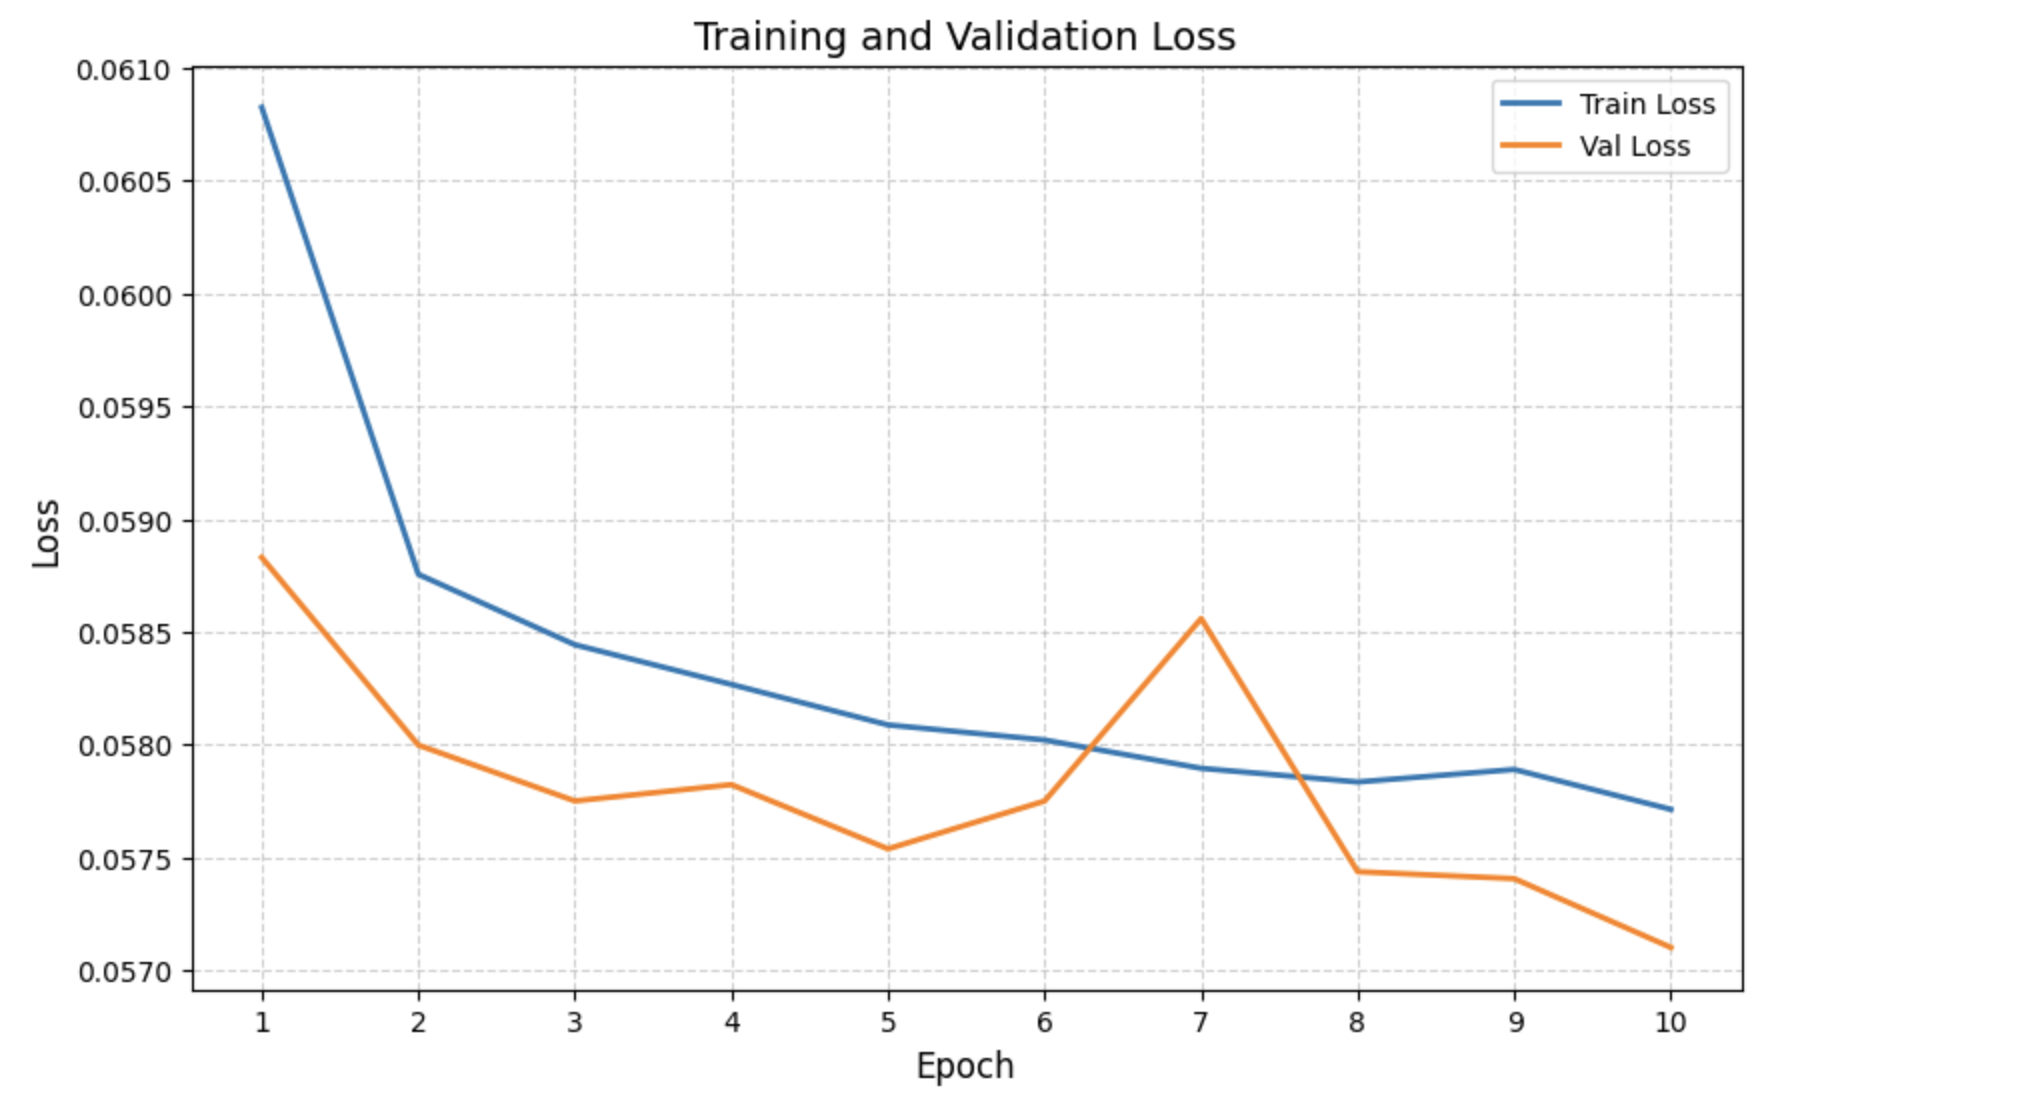

The model achieves the minimum validation loss (0.05710171274840832) at Epoch 10, which is the optimal training effect.

| Epoch | Train Loss          | Val Loss            | Remarks                  |
| :-----| :------------------ | :------------------ | :----------------------- |
| 1     | 0.060824171819079384 | 0.058830059692263605 | -                        |
| 2     | 0.05875525654365237  | 0.05799848958849907  | -                        |
| 3     | 0.05844311518952824  | 0.05775078646838665  | -                        |
| 4     | 0.05826718815817283  | 0.057823197543621065 | -                        |
| 5     | 0.05808785672371204  | 0.057538489997386935 | -                        |
| 6     | 0.05802099554298016  | 0.05775033086538315  | -                        |
| 7     | 0.057895506373964824 | 0.05855925194919109  | -                        |
| 8     | 0.05783492701772887  | 0.05743729174137115  | -                        |
| 9     | 0.05789036482142714  | 0.05740649811923504  | -                        |
| 10    | 0.05771359237484061  | 0.05710171274840832  | **Best Performance**     

### Qualitative results

Prediction VS GT

In [ ]:
import torch
import h5py
import numpy as np
import matplotlib.pyplot as plt
from predicting_unpredictable.plot import plot_prediction_comparison
from predicting_unpredictable.models.task1 import Task1CNNBaseline

h5_path = "data/train.h5"
ckpt_path = "notebooks-final/checkpoints/task1_baseline_best.pt"
storm_id = "S832818"
start_t = 0
IN_LEN, OUT_LEN = 12, 12

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
model = Task1CNNBaseline().to(device).eval()
model.load_state_dict(sd, strict=True)
with h5py.File(h5_path, "r") as f:
    vil = f[storm_id]["vil"][:, :, :]  # (H,W,T) uint8

x = vil[:, :, start_t:start_t+IN_LEN].astype(np.float32) / 255.0          # (H,W,12)
y = vil[:, :, start_t+IN_LEN:start_t+IN_LEN+OUT_LEN].astype(np.float32) / 255.0  # (H,W,12)
xb = torch.from_numpy(x).permute(2,0,1).unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(xb).clamp(0,1)[0].cpu().numpy()  
gt = np.transpose(y, (2,0,1)) 

plot_prediction_comparison(
    pred, gt,
    frame_indices=[0, 3, 7, 11], 
    cmap="turbo",
    suptitle=f"CNN baseline | {storm_id} | start_t={start_t}"
)


In [ ]:
import os
from predicting_unpredictable.models.task1 import Task1CNNBaseline
from predicting_unpredictable.plot import make_gif  
from io import BytesIO
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import PIL.Image
from IPython.display import Image, display

@torch.no_grad()
def show_task1_cnn_gif(
    *,
    storm_id: str,
    h5_path: str = "data/train.h5",
    ckpt_path: str = "notebooks-final/checkpoints/task1_baseline_best.pt",
    start_t: int = 0,
    in_len: int = 12,
    out_len: int = 12,
    fps: int = 5,
    cmap: str = "turbo",
    device: torch.device | None = None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    ckpt = torch.load(ckpt_path, map_location=device)
    sd = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
    model = Task1CNNBaseline().to(device).eval()
    model.load_state_dict(sd, strict=True)
    with h5py.File(h5_path, "r") as f:
        vil_u8 = f[storm_id]["vil"][:]  

    T_total = vil_u8.shape[-1]
    if start_t + in_len + out_len > T_total:
        raise ValueError(f"Need {start_t+in_len+out_len} frames but only {T_total} in {storm_id}")

    x = vil_u8[:, :, start_t:start_t+in_len].astype(np.float32) / 255.0
    y = vil_u8[:, :, start_t+in_len:start_t+in_len+out_len].astype(np.float32) / 255.0

    xb = torch.from_numpy(x).permute(2,0,1).unsqueeze(0).to(device)  
    pred = model(xb).clamp(0,1)[0].cpu().numpy()                    
    gt = np.transpose(y, (2,0,1))                                   
    frames = []
    for k in range(out_len):
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(gt[k], vmin=0, vmax=1, cmap=cmap)
        axs[0].set_title(f"GT (lead {k+1})"); axs[0].axis("off")

        axs[1].imshow(pred[k], vmin=0, vmax=1, cmap=cmap)
        axs[1].set_title(f"Pred (lead {k+1})"); axs[1].axis("off")

        err = np.abs(pred[k] - gt[k])
        axs[2].imshow(err, vmin=0, vmax=0.5, cmap="magma")
        axs[2].set_title("|Pred-GT|"); axs[2].axis("off")

        buf = BytesIO()
        fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0.02, facecolor="white")
        plt.close(fig)
        buf.seek(0)
        frames.append(PIL.Image.open(buf).convert("RGB"))

    gif_buf = BytesIO()
    frames[0].save(
        gif_buf, format="GIF", append_images=frames[1:],
        save_all=True, duration=int(1000/fps), loop=0
    )
    gif_buf.seek(0)
    display(Image(data=gif_buf.getvalue()))

show_task1_cnn_gif(storm_id="S832818", start_t=0)

### Conclusion (CNN baseline)

From the forecast GIFs, the CNN baseline shows very limited temporal evolution: predicted frames often resemble a smoothed version of the most recent observations, with weak or missing motion dynamics. This behavior is expected because the baseline treats the 12 input frames as channels and applies only a shallow 2D convolutional mapping, so each future lead time is produced by a static spatial mixing of the input channels rather than an explicit temporal model of advection or growth/decay.

A consistent artifact is that later lead times become noticeably darker (lower intensity). This reflects a conservative bias under L1/MAE training: high-VIL cores are sparse and difficult to localize, and MAE is minimized by underestimating peaks and regressing toward the global mean/background. As uncertainty increases with lead time, the model increasingly collapses toward low-amplitude predictions, yielding over-smoothed and dissipated forecasts.


# Model Extensions and Results

### Motivation

The CNN baseline treats the full 12-frame history as a static stack and has no explicit mechanism to propagate temporal state. Task 1, however, is fundamentally a **spatiotemporal forecasting** problem: storms move, split, intensify, and dissipate.

To better model dynamics and retain spatial detail, I extend the baseline to a **ConvLSTM-UNet**:

- **ConvLSTM bottleneck**: maintains a hidden state over time, helping track motion and temporal evolution.
- **U-Net skip connections**: preserve fine-grained spatial structure so the model can better reconstruct sharp storm cores.

### Loss design (addressing EDA challenges)

EDA shows VIL is long-tailed and high-VIL cores are sparse. Plain L1 tends to favor conservative, over-smoothed predictions. I therefore use a composite loss during training:

- **Base L1**: aligns with the evaluation metric.
- **Lead-time weighting**: later frames are harder; increasing their weight encourages longer-horizon skill.
- **Intensity weighting**: up-weights pixels where the target exceeds a threshold (focus on storm cores).
- **TV regularization**: reduces speckle/noise in predicted fields.
- **Range penalty**: discourages values outside `[0,1]` prior to clamping.

Results are reported with the same metrics/visualisations as the baseline for a fair comparison.

### ConvLSTM-UNet Training Setup (used for the saved best checkpoint)

### Data / sliding window
- Input/output horizon: **12 → 12** frames (IN_LEN=12, OUT_LEN=12).
- Training samples are generated with a sliding window over each storm sequence.
- **Training stride:** `stride = 4` (i.e., we take every 4th possible window to reduce redundancy and speed up training).
- **Validation windows:** `t = 0` per storm (one fixed window per validation storm for a consistent and cheap evaluation).

### Optimization
- Optimizer: **Adam**
- Learning rate: **1e-3**
- Batch size: **4**
- Epochs: **30**
- Gradient clipping: **max norm = 1.0**
- Output range: predictions are clamped to **[0, 1]** for evaluation (VIL is normalized to [0,1]).

### Loss function (composite training loss)
We train with a composite objective to better handle long-tailed VIL intensities and longer lead times:
$$
\mathcal{L}
= (1-\alpha)\,\mathcal{L}_{\text{L1}}
+ \alpha\,\mathcal{L}_{\text{w-lead}}
+ \lambda_{\text{int}}\,\mathcal{L}_{\text{int}}
+ \lambda_{\text{tv}}\,\mathcal{L}_{\text{tv}}
+ \lambda_{\text{range}}\,\mathcal{L}_{\text{range}}
\quad (+\ \lambda_{\text{ssim}}\,\mathcal{L}_{\text{ssim}}\ \text{if enabled})
$$

Where:
- Base L1 (MAE): plain pixel-wise L1 over all forecast frames.
- Weighted-lead L1: increases weight for later lead times and for pixels above a threshold.
- Intensity loss: up-weights errors on stronger echoes (piecewise weights at 20/255, 80/255, 160/255).
- TV regularization: encourages spatial smoothness and reduces speckle noise.
- Range penalty: discourages values outside [0,1] before clamping.

**Weights used in the best-checkpoint run:**
- `mix_w (α) = 0.2`
- `int_w (λ_int) = 0.2`
- `tv_w (λ_tv) = 0.005`
- `range_w (λ_range) = 0.01`
- `w_pos = 5.0`, `thr = 20/255`, `lead_power = 0.5`
- SSIM term: **disabled** in this run (`ssim_w = 0`)

### Model selection criterion
- The **best checkpoint** is selected by the **lowest validation composite loss** (`val_loss`) during training.
- For reporting, we also compute validation **MAE** (plain L1) from the best checkpoint for comparability with the official metric.


### Extension results (ConvLSTM-UNet)

**Insert results here:**

- Overall validation MAE: **`[0.0414]`**
- loss

In [ ]:
import json
import importlib
from pathlib import Path

import predicting_unpredictable.plot as plot

loss_log_path = "notebooks-final/checkpoints/task1_unet_best.loss.jsonl"

history = {"train_loss": [], "val_loss": []}
with open(loss_log_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        row = json.loads(line)
        history["train_loss"].append(row["train_loss"])
        history["val_loss"].append(row["val_loss"])
fig = plot.plot_training_curves(history, title="ConvLSTM-UNet Training Curves")


The ConvLSTM-UNet converges rapidly in the first few epochs and then enters a plateau regime. Training loss keeps decreasing steadily to ~0.091 by epoch 30, while validation loss stabilizes around ~0.10 with mild oscillations. The best validation performance occurs around epoch ~28 (val_loss ≈ 0.099), after which validation no longer improves despite continued training improvements, suggesting mild overfitting and that early stopping around the best epoch is appropriate. The small fluctuations in validation are expected given the composite loss (lead-time and intensity weighting) and the evaluation protocol using a single fixed window (t=0) per validation storm.

The model achieves the minimum validation loss (0.09912945982068777) at Epoch 28, which is the optimal training effect 

| Epoch | Train Loss          | Val Loss            | Remarks                  |
| :-----| :------------------ | :------------------ | :----------------------- |
| 1     | 0.1649252763018012  | 0.12716954182833434 | -                        |
| 2     | 0.12785562995704822 | 0.12334631392732262 | -                        |
| 3     | 0.1225843713618815  | 0.11814539423212408 | -                        |
| 4     | 0.11867590510519221 | 0.11639234339818358 | -                        |
| 5     | 0.11636016226839274 | 0.11526208771392703 | -                        |
| 6     | 0.11373366949846968 | 0.11504134815186262 | -                        |
| 7     | 0.11191747853590642 | 0.11202974542975426 | -                        |
| 8     | 0.11058540520898533 | 0.10866980422288179 | -                        |
| 9     | 0.10856638670666144 | 0.10857629543170333 | -                        |
| 10    | 0.10707088455674238 | 0.10618876395747065 | -                        |
| 11    | 0.10542615249869414 | 0.10567775182425976 | -                        |
| 12    | 0.10409836075850762 | 0.1090952767059207  | -                        |
| 13    | 0.10299918371019885 | 0.10555522199720144 | -                        |
| 14    | 0.10197612710180692 | 0.10411676168441772 | -                        |
| 15    | 0.1010431035363581  | 0.10219335472211241 | -                        |
| 16    | 0.10074958047480323 | 0.10314923720434307 | -                        |
| 17    | 0.09967055600427557 | 0.10477962186560034 | -                        |
| 18    | 0.09869906200910919 | 0.10134731372818351 | -                        |
| 19    | 0.09791448508040049 | 0.10116310752928256 | -                        |
| 20    | 0.09777590920566581 | 0.10104222977533936 | -                        |
| 21    | 0.0967845500796102  | 0.09995087906718254 | -                        |
| 22    | 0.09572545189585072 | 0.10561047066003085 | -                        |
| 23    | 0.09639368380594533 | 0.10019643008708953 | -                        |
| 24    | 0.09419239889248274 | 0.0998584651388228  | -                        |
| 25    | 0.09406363954767585 | 0.10100725237280131 | -                        |
| 26    | 0.09335033740499057 | 0.10197575092315674 | -                        |
| 27    | 0.09262099656625651 | 0.09973511788994074 | -                        |
| 28    | 0.09293428634409792 | 0.09912945982068777 | **Best Performance**     |
| 29    | 0.09130001230805647 | 0.10021122144535184 | -                        |
| 30    | 0.09091687639884186 | 0.10009595938026905 | -                        |

**Insert figures here (extension):**
- **Figure F**: Same visualization as baseline (Pred vs GT grids for 3–5 storms).
- **Figure G**: GIF comparasion



In [ ]:
import predicting_unpredictable.plot as pu_plot
importlib.reload(pu_plot)
from predicting_unpredictable.plot import plot_prediction_comparison

from predicting_unpredictable.models.task1 import BottleneckConvLSTMUNet

h5_path = "data/train.h5"
ckpt_path = "notebooks-final/checkpoints/task1_unet_best.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt

model = BottleneckConvLSTMUNet(in_channels=1, out_channels=12, base=8).to(device).eval()
model.load_state_dict(sd, strict=True)

IN_LEN, OUT_LEN = 12, 12

@torch.no_grad()
def predict_one_storm_unet(storm_id: str, start_t: int = 0):
    with h5py.File(h5_path, "r") as f:
        vil_u8 = f[storm_id]["vil"][:, :, :]  # (H,W,T) uint8

    x = vil_u8[:, :, start_t:start_t+IN_LEN].astype(np.float32) / 255.0
    y = vil_u8[:, :, start_t+IN_LEN:start_t+IN_LEN+OUT_LEN].astype(np.float32) / 255.0
    xb = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).unsqueeze(2).to(device) 

    pred = model(xb).clamp(0, 1)[0].cpu().numpy() 
    gt   = np.transpose(y, (2, 0, 1))              
    return pred, gt

storm_ids = ["S832818", "S778114"]  
start_t = 0

for sid in storm_ids:
    pred, gt = predict_one_storm_unet(sid, start_t=start_t)

    plot_prediction_comparison(
        pred, gt,
        frame_indices=[0, 5, 11],   
        cmap="turbo",
        suptitle=f"ConvLSTM-UNet | {sid} | start_t={start_t}"
    )


GIF comparasion

In [ ]:
@torch.no_grad()
def show_unet_pred_gt_gif(storm_id: str, start_t: int = 0, fps: int = 4, vmin: float = 0.0, vmax: float = 1.0):
    pred, gt = predict_one_storm_unet(storm_id, start_t=start_t)  
    tmp_pngs = []
    for k in range(pred.shape[0]):
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(gt[k],   vmin=vmin, vmax=vmax, cmap="turbo")
        axs[0].set_title(f"GT (+{k+1})")
        axs[1].imshow(pred[k], vmin=vmin, vmax=vmax, cmap="turbo")
        axs[1].set_title(f"Pred (+{k+1})")
        axs[2].imshow(np.abs(pred[k] - gt[k]), cmap="magma")
        axs[2].set_title("|Pred - GT|")
        for ax in axs:
            ax.axis("off")

        fn = f"_tmp_{storm_id}_{k:02d}.png"
        fig.savefig(fn, bbox_inches="tight", pad_inches=0.02, facecolor="white")
        plt.close(fig)
        tmp_pngs.append(fn)

    gif_path = f"_tmp_{storm_id}_compare.gif"
    make_gif(gif_path, tmp_pngs, fps=fps, loop=0, display=False)

    display(Image(filename=gif_path))
    for f in tmp_pngs:
        if os.path.exists(f):
            os.remove(f)
    if os.path.exists(gif_path):
        os.remove(gif_path)

show_unet_pred_gt_gif("S832818", start_t=0, fps=4)

### Conclusion (Qualitative)

From the GIF and the Pred-vs-GT grids, the ConvLSTM-UNet clearly captures temporal evolution: storm structures translate, deform, and partially intensify/dissipate across lead times, instead of producing nearly static forecasts as in the CNN baseline. 

Qualitatively, the model also preserves spatial structure more faithfully. Thanks to the U-Net skip connections, predicted echoes maintain sharper boundaries and more realistic storm shapes, and the main high-VIL regions are generally aligned with the ground truth (smaller spatial displacement). Overall, the extension demonstrates meaningful spatiotemporal forecasting skill with improved motion realism and better morphological accuracy compared to the baseline.


# Discussion

### Summary

This task is challenging because the future VIL field depends on both **advective motion** (storm translation) and **nonlinear intensity evolution** (growth/decay). EDA also suggests a strong imbalance in pixel intensities (high-VIL cores are rare). As a result, models optimized with plain L1/MAE can obtain a reasonable *average* error while still failing to reproduce the most important storm-core structure.

In my experiments:

- **CNN baseline (2-layer Conv)** achieves a competitive overall validation MAE (~0.057 in my run), but qualitative results show limited temporal evolution.  
  This happens because the model treats the 12 input frames as a **static channel stack** and has no explicit temporal state. Under an L1 objective with sparse high-VIL pixels, it is often optimal to predict a conservative, smoothed “average” field, which can look nearly time-invariant in GIFs even if the MAE is not terrible.

- **ConvLSTM-UNet extension** better reflects time-varying dynamics (translation/deformation of echoes) while also preserving sharper spatial structure via U-Net skip connections and better MAE(~0.0414).
  With my composite loss (weighted lead-time term + intensity weighting + TV + range penalty), the model visually tracks motion more realistically and maintains storm morphology more faithfully than the CNN baseline.

### Limitations

- **Intrinsic uncertainty**: at longer lead times the evolution becomes chaotic; deterministic point forecasts tend to blur plausible futures and may under-estimate peaks.
- **Imbalance and calibration trade-offs**: even with intensity weighting, high-VIL pixels remain hard; reweighting can shift errors between false positives (over-predicting cores) and false negatives (missing peaks).
- **Evaluation protocol and compute**: validation used a fixed window (**t = 0**) per storm for efficiency, which may not fully represent performance across all windows. More exhaustive validation (all windows) and hyperparameter sweeps would require additional compute.

### Future work

If more time were available, I would explore a stronger temporal/generative models (e.g., deeper ConvLSTM variants or GAN-based predictors) to produce sharper, more realistic forecasts or richer penalty mechanisms (e.g., stronger lead-time/intensity weighting, multi-scale or edge/gradient losses, and optional SSIM-style terms) to reduce late-lead blurring and peak-intensity underestimation since in the last few outputs the prediction is a bit unclear in details and the peak nearly disapperars.
 

### Bonus Task
#### 1. Scaling Law Experiments
- Dataset Size Impact: Quick scaling experiments were conducted on Task 1 using a 20% training subset (reduced from 8,320 to 1,664 windows) with 5 training epochs. The results indicate that reducing the dataset size leads to a slight degradation in model performance compared to full-dataset training. For the ConvLSTM-UNet model with a plain L1 loss function, the 20% subset achieved a validation L1 loss of approximately 0.0558, with lead-time mean absolute errors (MAEs) of 0.0307 (lead1), 0.0516 (lead6), and 0.0655 (lead12).

- Objective Function Impact: 
        

  - The introduction of structure-aware objective functions (e.g., L1 + SSIM) yielded a modest performance improvement, achieving a validation L1 loss of approximately 0.0519 at the 5th epoch. This combination effectively preserved large-scale storm structures but failed to consistently enhance the sharpness of high-VIL cores.

  - Stronger spatial regularization (e.g., total variation (TV) or gradient penalties) resulted in a similar validation loss (approximately 0.0524 in 5-epoch training) but tended to smooth textures and suppress intensity peaks in actual visualizations. This phenomenon may lead to forecasts that appear "closer to the background" even when the average MAE remains at a reasonable level.

- Model Capacity Impact: Model capacity followed the expected compute-accuracy trade-off:
        

  - The CNN baseline exhibited lower computational cost but tended to converge to conservative, over-smoothed "average" solutions.

  - The ConvLSTM-UNet outperformed the CNN baseline in preserving spatiotemporal structures by maintaining an explicit temporal state.

  - Increasing model width (e.g., from base=8 to base=16) increased memory consumption but did not improve performance in short-term training runs.

  - Using a denser sliding window to increase the number of training samples contributed to performance improvement, but at the cost of a substantial increase in training overhead.

- Normalization and Output-Range Handling: Normalization and output-range control significantly affected the visual quality of predictions:
        

  - Since VIL data was normalized to the [0,1] range, predictions were clamped to this interval during evaluation.

  - The application of an additional sigmoid function or clamp operation within the model compressed the dynamic range of outputs, resulting in darker and less detailed predictions, even with minimal changes in MAE.

  - Different input normalization methods (e.g., z-score normalization, min-max normalization) did not significantly alter experimental outcomes.

#### 2. Prediction Explanation

- Qualitative and Diagnostic Visualization Validation: The rationality of model predictions was verified through qualitative analysis and diagnostic visualizations:
        

  - Prediction-Ground Truth (Pred-GT) GIFs demonstrated that the CNN baseline often generated temporally static, over-smoothed forecasts, which is consistent with its inherent limitation of treating input sequences as static stacks. In contrast, the ConvLSTM-UNet produced more coherent temporal evolution, with storm structures translating consistently and maintaining their shapes more effectively across different lead times—attributed to its explicit modeling of the time dimension, which the CNN baseline lacks.

  - Error maps (|Pred−GT|) revealed that prediction errors were primarily concentrated around sharp storm-core boundaries and high-intensity regions, and error magnitudes increased with lead time. Specifically, predictions were highly accurate in the first 1–2 lead times but gradually decreased in accuracy for longer lead times. This observation is consistent with the intrinsic uncertainty of long-horizon nowcasting and the long-tailed distribution characteristic of VIL data.

- Model Evaluation and Optimization Criteria: A straightforward approach to model evaluation and optimization is visual inspection of prediction results (e.g., image predictions). Quantitatively, MAE is used to measure the discrepancy between predicted values and ground truth, where a smaller MAE indicates a smaller deviation between predictions and actual results.